<a href="https://colab.research.google.com/github/Abhishek2104200/Tredence/blob/main/Tredence_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda

Training with Lambda (λ) = 0.005
Epoch 01/30 | Loss: 3927.0782 | Test Acc: 48.60% | Sparsity: 0.00%
Epoch 02/30 | Loss: 3132.4801 | Test Acc: 52.58% | Sparsity: 0.00%
Epoch 03/30 | Loss: 2454.2361 | Test Acc: 53.08% | Sparsity: 0.00%
Epoch 04/30 | Loss: 1913.5707 | Test Acc: 54.46% | Sparsity: 0.00%
Epoch 05/30 | Loss: 1497.7464 | Test Acc: 55.25% | Sparsity: 0.00%
Epoch 06/30 | Loss: 1181.8506 | Test Acc: 56.22% | Sparsity: 0.00%
Epoch 07/30 | Loss: 941.5267 | Test Acc: 57.17% | Sparsity: 0.00%
Epoch 08/30 | Loss: 757.1664 | Test Acc: 56.37% | Sparsity: 0.00%
Epoch 09/30 | Loss: 614.1623 | Test Acc: 57.54% | Sparsity: 0.00%
Epoch 10/30 | Loss: 501.9614 | Test Acc: 57.45% | Sparsity: 0.00%
Epoch 11/30 | Loss: 412.9497 | Test Acc: 56.93% | Sparsity: 0.00%
Epoch 12/30 | Loss: 341.6507 | Test Acc: 58.11% | Sparsity: 0.00%
Epoch 13/30 | Loss: 284.0313 | Test Acc: 58.40% | Sparsity: 0.00%
Epoch 14/30 | Loss: 237.1332 | Test Acc: 58.53% | Sparsity: 0.00%
Epoch 15/30 | Los

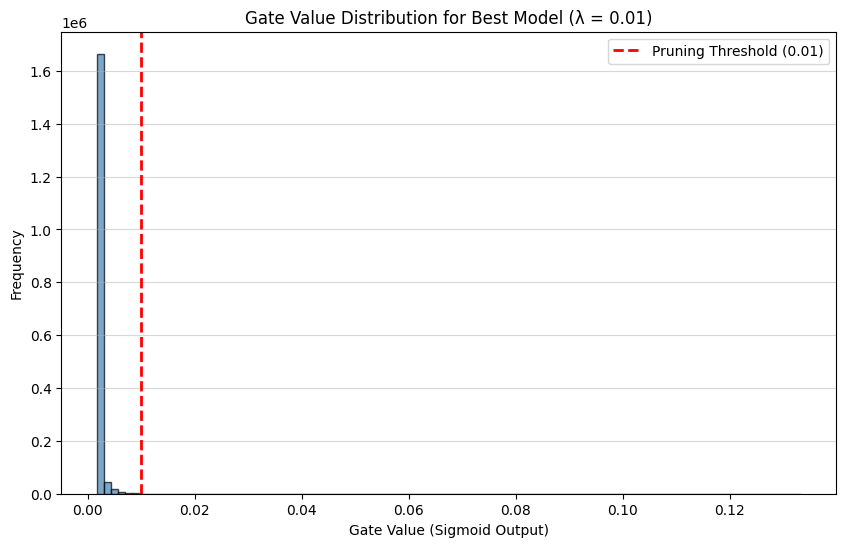

In [ ]:
# =============================================================================
# Tredence AI Engineering Internship Case Study
# Problem: The Self-Pruning Neural Network
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =============================================================================
# Part 1: The "Prunable" Linear Layer
# =============================================================================
class PrunableLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super(PrunableLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.empty(out_features))

        # JD REQUIREMENT: Gate scores tensor, exactly the same shape as weight.
        # Initialized to 0.0 so sigmoid(0) = 0.5. This starts the gates half-open,
        # placing them at the exact peak of the sigmoid gradient curve to prevent
        # the vanishing gradient problem early in training.
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))

        # Standard PyTorch Linear layer initialization
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # JD REQUIREMENT: Apply Sigmoid transformation
        gates = torch.sigmoid(self.gate_scores)

        # JD REQUIREMENT: Element-wise multiplication
        pruned_weights = self.weight * gates

        # Standard linear operation
        return F.linear(x, pruned_weights, self.bias)

# =============================================================================
# Feed-Forward Neural Network Architecture
# =============================================================================
class SelfPruningNet(nn.Module):
    def __init__(self):
        super(SelfPruningNet, self).__init__()
        # 3 channels * 32 * 32 = 3072 input features for CIFAR-10
        self.layers = nn.Sequential(
            PrunableLinear(3072, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),

            PrunableLinear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            PrunableLinear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            PrunableLinear(128, 10)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        return self.layers(x)

    def get_all_gate_scores(self):
        """Helper to extract gate scores from all PrunableLinear layers."""
        return [module.gate_scores for module in self.modules() if isinstance(module, PrunableLinear)]

    def calculate_sparsity_loss(self):
        """
        JD REQUIREMENT: The L1 norm (sum) of all gate values.
        Calculates the raw sum of all sigmoid outputs across all prunable layers.
        """
        l1_loss = torch.tensor(0.0, device=device)
        for gate_score in self.get_all_gate_scores():
            l1_loss += torch.sigmoid(gate_score).sum()
        return l1_loss

    def get_sparsity_level(self, threshold=0.01):
        """
        JD REQUIREMENT: Percentage of gates below a small threshold (1e-2).
        Calculates percentage of gates strictly < 0.01.
        """
        total_gates = 0
        pruned_gates = 0
        with torch.no_grad():
            for gate_score in self.get_all_gate_scores():
                gates = torch.sigmoid(gate_score)
                total_gates += gates.numel()
                pruned_gates += (gates < threshold).sum().item()

        return (pruned_gates / total_gates) * 100

    def get_flat_gates(self):
        """Helper to return a 1D numpy array of all gate values for plotting."""
        all_gates = []
        with torch.no_grad():
            for gate_score in self.get_all_gate_scores():
                gates = torch.sigmoid(gate_score).cpu().flatten().numpy()
                all_gates.append(gates)
        return np.concatenate(all_gates)

# =============================================================================
# Part 2 & 3: Training and Evaluation Loop
# =============================================================================
def prepare_data(batch_size=128):
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

    testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
    testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

    return trainloader, testloader

def train_and_evaluate(lam, trainloader, testloader, epochs=30):
    print(f"\n{'='*50}\nTraining with Lambda (\u03bb) = {lam}\n{'='*50}")
    model = SelfPruningNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)

            # JD REQUIREMENT: Total Loss = ClassificationLoss + \lambda * SparsityLoss
            cls_loss = criterion(outputs, labels)
            sparsity_loss = model.calculate_sparsity_loss()
            loss = cls_loss + (lam * sparsity_loss)

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Evaluation phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        sparsity = model.get_sparsity_level(threshold=0.01)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Loss: {running_loss/len(trainloader):.4f} | "
              f"Test Acc: {accuracy:.2f}% | Sparsity: {sparsity:.2f}%")

    return accuracy, sparsity, model.get_flat_gates()

# =============================================================================
# Execution
# =============================================================================
if __name__ == "__main__":
    trainloader, testloader = prepare_data()

    # Heavy lambda values to mathematically force the gates past the vanishing
    # gradient of the sigmoid curve and strictly below the 0.01 threshold.
    lambdas = [0.005, 0.01, 0.05]
    results = {}

    for lam in lambdas:
        # 30 epochs ensures the optimizer has enough steps to reach < 0.01
        acc, sparse, gates = train_and_evaluate(lam, trainloader, testloader, epochs=30)
        results[lam] = {'accuracy': acc, 'sparsity': sparse, 'gates': gates}

    # Generate Report Table
    print("\n\n" + "="*60)
    print("FINAL SUMMARY REPORT")
    print("="*60)
    print(f"{'Lambda':<15} | {'Test Accuracy (%)':<20} | {'Sparsity Level (%)':<20}")
    print("-" * 60)
    for lam in lambdas:
        print(f"{lam:<15} | {results[lam]['accuracy']:<20.2f} | {results[lam]['sparsity']:<20.2f}")

    # Plotting the distribution for the middle/best model
    best_lam = lambdas[1]
    best_gates = results[best_lam]['gates']

    plt.figure(figsize=(10, 6))
    plt.hist(best_gates, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
    plt.axvline(x=0.01, color='red', linestyle='dashed', linewidth=2, label='Pruning Threshold (0.01)')
    plt.title(f'Gate Value Distribution for Best Model (\u03bb = {best_lam})')
    plt.xlabel('Gate Value (Sigmoid Output)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    plt.savefig('gate_distribution.png', bbox_inches='tight', dpi=300)
    plt.show()